In [1]:
from tradepy.data.loader import load_future
from tradepy.config.config import load_config, load_symbols, load_feature_config, load_exclude_config
from tradepy.data.cleaner import add_trading_date_by_gap
from tradepy.data.resampler import resample_ohlcv, daily_ohlcv_cummulative
from tradepy.features.generate import generate_features
from tradepy.features.quality_check import data_quality_report
from tradepy.supervised.load import prepare_all
from tradepy.paths import EXCLUDE_CONFIG, SYSTEM_CONFIG
from tradepy.supervised.target import target_triple_barrier_interday
from tradepy.supervised.pretrain import filter_features
from tradepy.supervised.models import GoldLSTM_L1_Move, GoldLSTM_L2_Dir, GoldGRU_L1_Move, GoldGRU_L2_Dir
from tradepy.supervised.train import train_walk_forward_2level, grid_search_thresholds
from tradepy.supervised.posttrain import evaluate_model_classification, tune_threshold_wf, save_trading_model_2level
from tradepy.paths import MODELS_DIR

In [2]:
symbols = load_symbols()
cfg = load_config()

In [3]:
symbols

['AD',
 'BP',
 'CL',
 'EC',
 'ES',
 'GC',
 'MFXI',
 'NG',
 'NQ',
 'YM',
 'ZB',
 'ZN',
 'ZS']

In [4]:
ASSET = symbols[5]
MINUTES             = cfg['sampling_minutes']        # 240
RETURN_HORIZON_MIN  = cfg['return_horizon_min']      # 2880

In [5]:
df_final, spec = prepare_all(ASSET, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Data/features_config.json")


In [6]:
spec

{'name': 'Gold',
 'symbol': 'GC',
 'ib_symbol': 'GC',
 'exchange': 'COMEX',
 'currency': 'USD',
 'approx_total_fee_per_side': 2.5,
 'min_slippage_ticks': 1,
 'max_spread_ticks': 4,
 'fallback_margin': 45000,
 'conId': 706903673,
 'multiplier': 100.0,
 'tick_size': 0.1,
 'tick_value': 10.0,
 'trading_hours': '20260425:CLOSED;20260426:1800-20260427:1700;20260427:1800-20260428:1330',
 'liquid_hours': '20260425:CLOSED;20260426:CLOSED;20260427:0930-20260427:1700;20260428:0930-20260428:1330',
 'min_profit_ticks': 2.5,
 'initial_margin': 44136.61,
 'maint_margin': 38379.66,
 'fetched_at': '2026-04-25T14:19:21.740096+00:00'}

In [7]:
exclude = load_exclude_config(MINUTES)

In [8]:
exclude

{'exclude_cols_triple': ['datetime',
  'dtyyyymmdd',
  'trading_date',
  'ticker',
  'per',
  'openint',
  'open',
  'high',
  'low',
  'close',
  'volume',
  'target_bin',
  'target_logret_240',
  'target_ret_240',
  'target_ticks_240'],
 'exclude_more': ['open_day',
  'bb_std',
  'true_range',
  'volume_cum',
  'vpt',
  'obv',
  'ad',
  'hour',
  'minute',
  'dayofweek',
  'day',
  'month',
  'swing_low',
  'swing_low_price',
  'swing_low_strength',
  'swing_high',
  'swing_high_price',
  'swing_high_strength']}

In [9]:
feature_cols_triple = [c for c in df_final.columns if c not in exclude['exclude_cols_triple']]

In [10]:
df_final_triple_real = target_triple_barrier_interday(df_final, spec, return_horizon_days=int(RETURN_HORIZON_MIN/60/24), profit_factor=1.8, tp_atr_mult=1.4, sl_atr_mult=1.2)
df_final_triple_real["target_class"] = df_final_triple_real[f"target_tb_{int(RETURN_HORIZON_MIN/60/24)}d"]

In [11]:
features_finales_test, params = filter_features(df_final_triple_real, feature_cols_triple, 'target_class')

Eliminando 59 features redundantes por correlación
Configuración sugerida:
{'lookback': 30, 'train_size': 6000, 'test_size': 180, 'gap': 12, '_candles_per_day': 6, '_horizon_bars': 12}
Features seleccionadas (60):
['open_day' 'volume_cum' 'signal' 'histogram' 'adx' 'rsi' 'slowk' 'cmo'
 'williams_r' 'cci' 'roc_10' 'roc_5' 'bb_std' 'hv' 'obv' 'obv_roc_5'
 'obv_roc_10' 'obv_z' 'ad_roc_5' 'ad_roc_10' 'ad_z' 'ad_rel' 'mfi' 'cmf'
 'efi' 'vwap' 'avg_volume' 'relative_volume' 'volume_z' 'volume_delta'
 'pct_above_ma_20' 'pct_above_ma_50' 'slope_10' 'dist_low_cum_ticks'
 'dist_open_day_ticks' 'vol_weight_intraday' 'hour_cos' 'is_london'
 'return_horizon_2880m' 'return_lag_1' 'return_lag_5' 'return_lag_10'
 'return_lag_20' 'return_std_5' 'return_z_5' 'return_std_10' 'return_z_10'
 'rolling_skew_10' 'rolling_kurt_10' 'rolling_skew_20' 'rolling_kurt_20'
 'dist_to_last_swing_high' 'dist_to_last_swing_low' 'swing_range'
 'swing_range_pct' 'close_in_swing_range' 'atr_z' 'dist_to_nearest_fib'
 'swing_

In [12]:
results, results_by_fold, model_l1, model_l2, sc = train_walk_forward_2level(
    df_final_triple_real,
    features_finales_test,
    'target_class',
    model_class_l1=GoldLSTM_L1_Move,
    model_class_l2=GoldLSTM_L2_Dir,
    train_size=params["train_size"],
    test_size=params["test_size"],
    gap=params["gap"],
    lookback=params["lookback"],
    epochs=15,
    batch_size=256,
    lr=5e-4,
    threshold_move=0.6,
    threshold_dir=0.55
)

WF 2-Level:   0%|          | 0/129 [00:00<?, ?it/s]E:\Futuro\MLAlgoTrading\TradingBots\tradepy\tradepy\supervised\train.py:321: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched_l1.step()
E:\Futuro\MLAlgoTrading\TradingBots\tradepy\tradepy\supervised\train.py:361: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-ra

📊 --- CLASIFICACIÓN POR CLASE ---
              precision    recall  f1-score   support

    SELL (0)       0.22      0.27      0.24      4578
    HOLD (1)       0.64      0.56      0.60     14444
     BUY (2)       0.21      0.23      0.22      4198

    accuracy                           0.45     23220
   macro avg       0.35      0.36      0.35     23220
weighted avg       0.48      0.45      0.46     23220



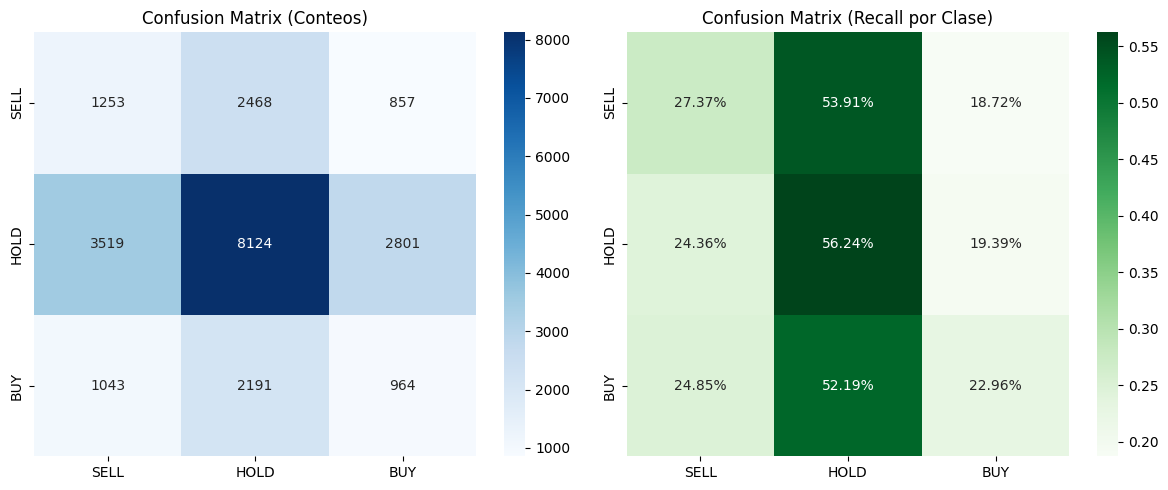


⭐ Métricas Globales:
Accuracy: 0.4453
F1-Score (Macro): 0.3522  <-- Si es < 0.33, el modelo es puro azar


{'accuracy': 0.44534883720930235, 'f1_macro': 0.35215950207034474}

In [13]:
evaluate_model_classification(results)

In [14]:
best_params, df_grid = grid_search_thresholds(results, metric='f1_macro')


Métrica: f1_macro
Mejor score: 0.3586 con {'threshold_move': 0.65, 'threshold_dir': 0.5}

Top 10:
 threshold_move  threshold_dir  f1_macro
           0.65           0.50    0.3586
           0.65            NaN    0.3586
           0.65           0.55    0.3550
           0.70           0.50    0.3530
           0.70            NaN    0.3530
           0.60           0.55    0.3522
           0.60           0.60    0.3514
           0.60            NaN    0.3511
           0.60           0.50    0.3511
           0.65           0.60    0.3498


In [15]:
results_gru, results_gru_by_fold, model_l1_gru, model_l2_gru, sc_gru = train_walk_forward_2level(
    df_final_triple_real,
    features_finales_test,
    'target_class',
    model_class_l1=GoldGRU_L1_Move,   # ← GRU
    model_class_l2=GoldGRU_L2_Dir,    # ← GRU
    train_size=params["train_size"],
    test_size=params["test_size"],
    gap=params["gap"],
    lookback=24,
    epochs=15,
    batch_size=256,
    lr=5e-4,
    threshold_move=0.6,
    threshold_dir=0.55
)

WF 2-Level:   0%|          | 0/129 [00:00<?, ?it/s]E:\Futuro\MLAlgoTrading\TradingBots\tradepy\tradepy\supervised\train.py:321: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched_l1.step()
E:\Futuro\MLAlgoTrading\TradingBots\tradepy\tradepy\supervised\train.py:361: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-ra

📊 --- CLASIFICACIÓN POR CLASE ---
              precision    recall  f1-score   support

    SELL (0)       0.24      0.24      0.24      4578
    HOLD (1)       0.64      0.61      0.63     14446
     BUY (2)       0.23      0.26      0.24      4196

    accuracy                           0.48     23220
   macro avg       0.37      0.37      0.37     23220
weighted avg       0.49      0.48      0.48     23220



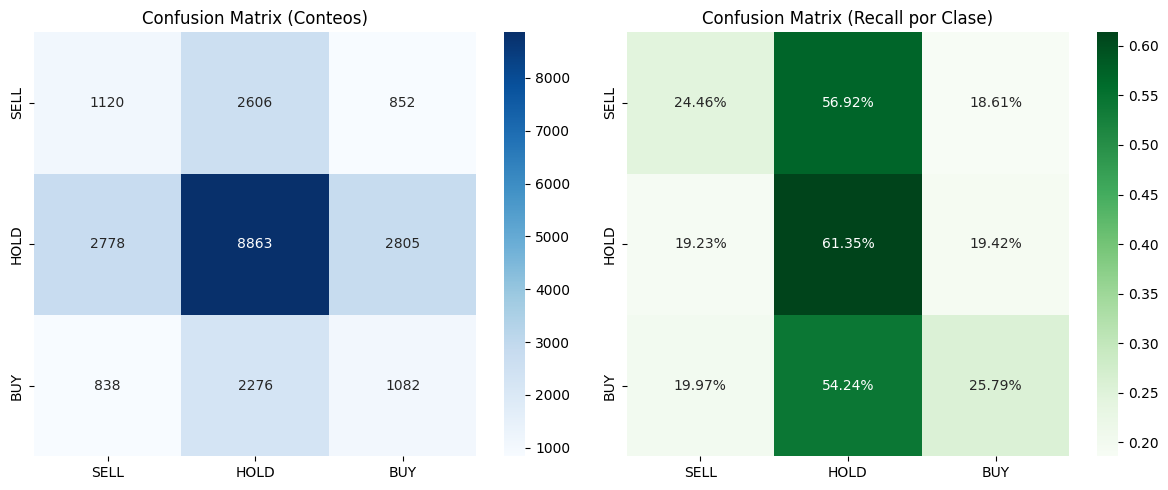


⭐ Métricas Globales:
Accuracy: 0.4765
F1-Score (Macro): 0.3705  <-- Si es < 0.33, el modelo es puro azar


{'accuracy': 0.4765288544358312, 'f1_macro': 0.37049134361634334}

In [16]:
evaluate_model_classification(results_gru)

In [17]:
best_params_gru, df_grid_gru = grid_search_thresholds(results_gru, metric='f1_macro')


Métrica: f1_macro
Mejor score: 0.3743 con {'threshold_move': 0.65, 'threshold_dir': 0.5}

Top 10:
 threshold_move  threshold_dir  f1_macro
           0.65           0.50    0.3743
           0.65            NaN    0.3743
           0.65           0.55    0.3712
           0.60           0.55    0.3705
           0.60            NaN    0.3683
           0.60           0.50    0.3683
           0.60           0.60    0.3682
           0.55           0.60    0.3671
           0.65           0.60    0.3644
           0.70           0.50    0.3643


In [18]:
model_params = {"input_dim": len(features_finales_test), "output_dim": 2}

save_trading_model_2level(
    model_l1, model_l2, sc,
    features_finales_test,
    model_params,
    best_thresholds=best_params,
    path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_lstm_2level"
)

# Para el GRU cuando lo tengas:
save_trading_model_2level(
    model_l1_gru, model_l2_gru, sc_gru,
    features_finales_test,
    model_params,
    best_thresholds=best_params_gru,
    path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_gru_2level"
)

✅ Modelos L1 y L2 guardados en: E:\Futuro\MLAlgoTrading\TradingBots\Models/gc/trading_model_lstm_2level
✅ Modelos L1 y L2 guardados en: E:\Futuro\MLAlgoTrading\TradingBots\Models/gc/trading_model_gru_2level
